# Examen 2

Nombre: **Claudia Iriel Serrano Sánchez**

### Física Computacional 2026-2

Resuelva los siguientes ejercicios.

1. Utilice la biblioteca de ```scipy.special``` para realizar la gráfica de la función $\Gamma (x)$ en el intervalo (0,5]. Ajuste la imagen de la gráfica para que el eje vertical se encuentre en el intervalo $[0,5]$ y el eje horizontal en el dominio antes mencionado.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gamma

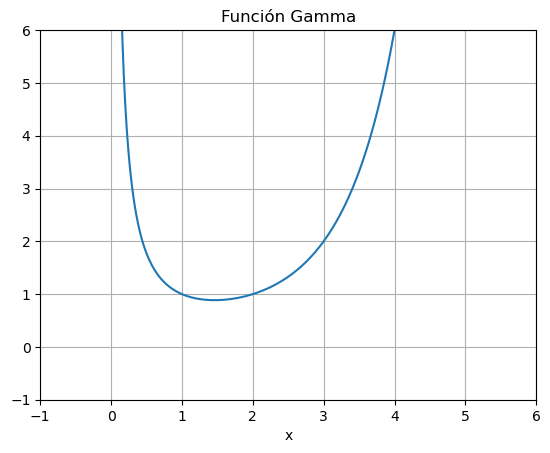

In [79]:
x = np.linspace(0.1, 10, 500)
y= gamma(x)

plt.plot(x,y)
plt.xlim(-1,6)
plt.ylim(-1,6)
plt.grid()
plt.title("Función Gamma")
plt.xlabel(r'x')
plt.show()


2. Se tiene la ecuación diferencial para $P(t)$

$$
\frac{dP}{dt} = rP \left( 1 - \frac{P}{P_c} \right)
$$

donde $r$ y $P_c$ son constantes positivas. Genere una función que se pueda utilizar para realizar una integración numérica de la ecuación diferencial y que además tenga como argumentos opcionales las dos constantes anteriores.

In [28]:
import numpy as np
import matplotlib.pyplot as plt

In [85]:
def f(t, P, r=1, Pc=10):
    return r * P * (1 - P/Pc)

In [86]:
def rk4(t0,tf,P0,h, r=1, Pc=10):
    t=np.arange(t0,tf+h,h)
    P=np.zeros(len(t))

    P[0]=P0

    for i in range(len(t)-1):
        k1=f(t[i], P[i], r, Pc)
        k2=f(t[i] + h/2, P[i] +h*k1/2, r, Pc)
        k3=f(t[i] + h/2, P[i] +h*k2/2, r, Pc)
        k4=f(t[i] + h, P[i] +h*k3, r, Pc)

        P[i+1] = P[i] + (h/6)*(k1 + 2*k2 + 2*k3 + k4)
    return t,P

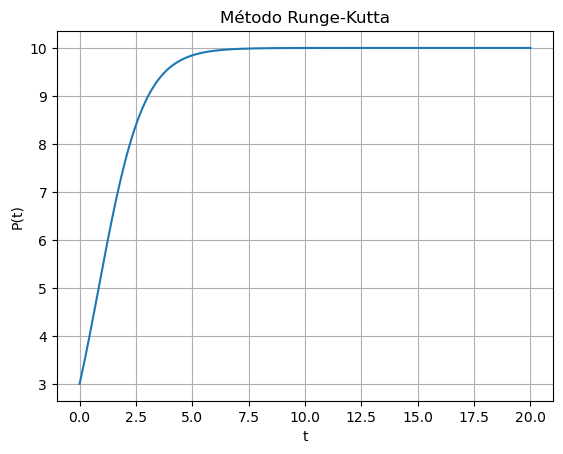

In [87]:
t, P = rk4(0,20,3,0.1)

plt.plot(t,P)
plt.xlabel("t")
plt.ylabel("P(t)")
plt.title("Método Runge-Kutta")
plt.grid()
plt.show()

3. Utilice la función [solve_ivp](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.solve_ivp.html) de scipy para encontrar la solución numérica de la ecuación anterior para $r=0.5$, $P_c = 10$ y las condiciones iniciales $P(0) = \{1,3,5, ... 19 \}$. Haga la gráfica de cada una de las soluciones.

*En la función solv_ivp, hay un argumento que se llama args=( ), que se puede utilizar para pasar los argumentos a la ecuación diferencial.*

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

In [51]:
def poblacion(t, P, r, Pc):
    return [r * P[0] * (1 - P[0]/Pc)]

t_eval = np.linspace(0, 20, 500)

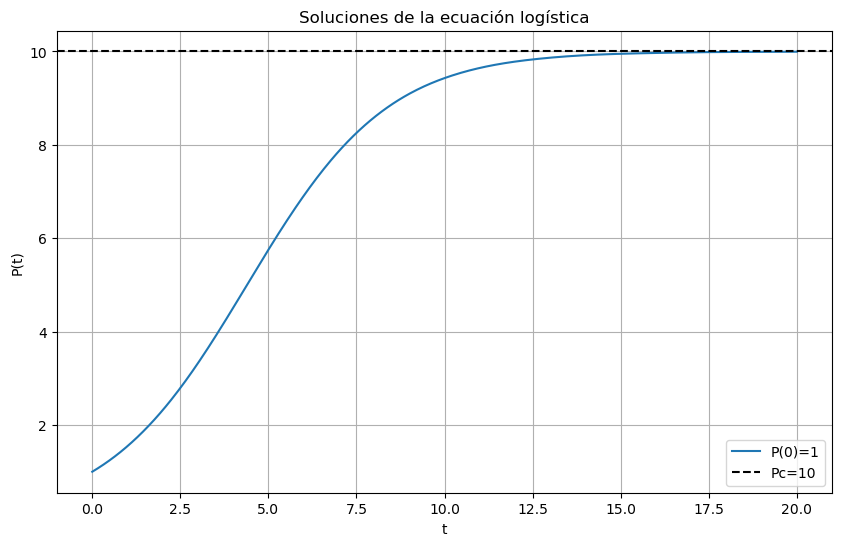

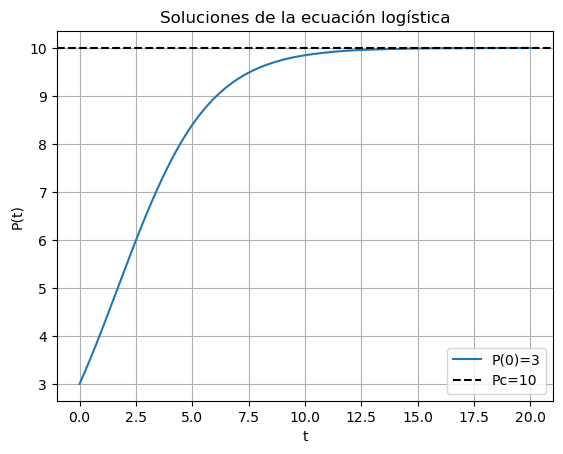

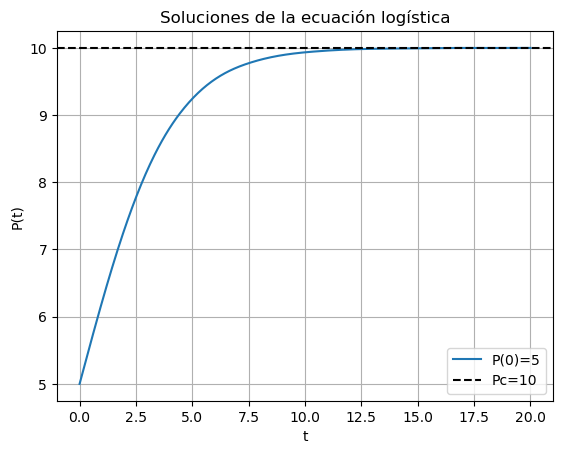

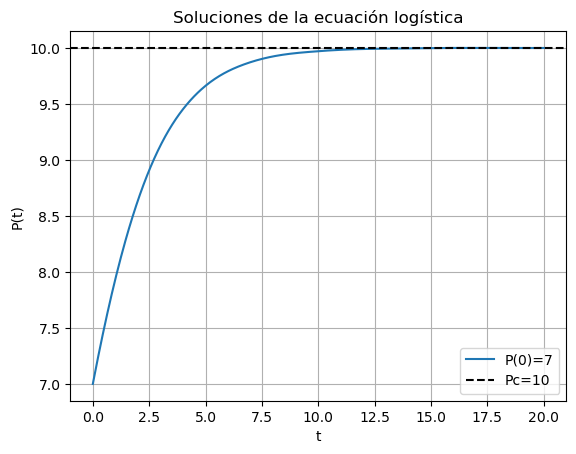

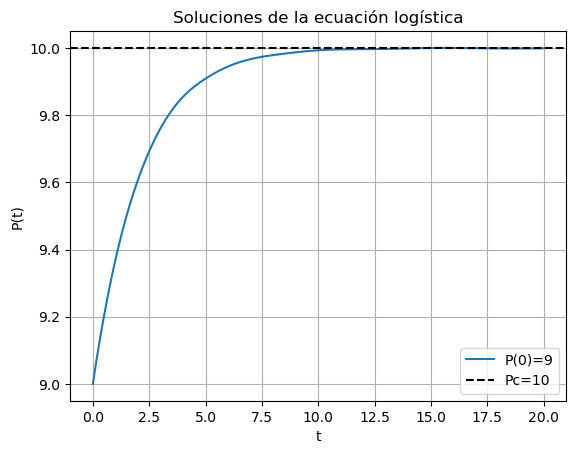

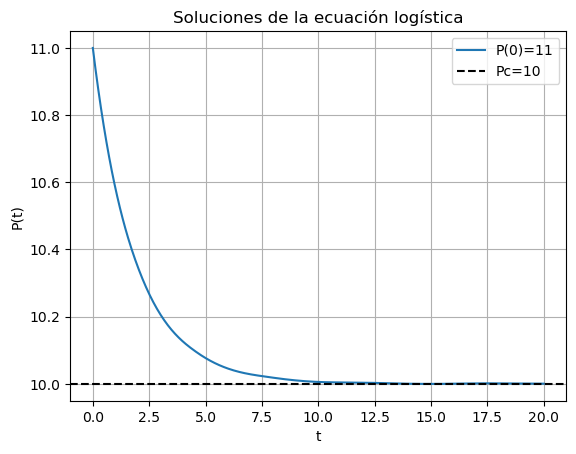

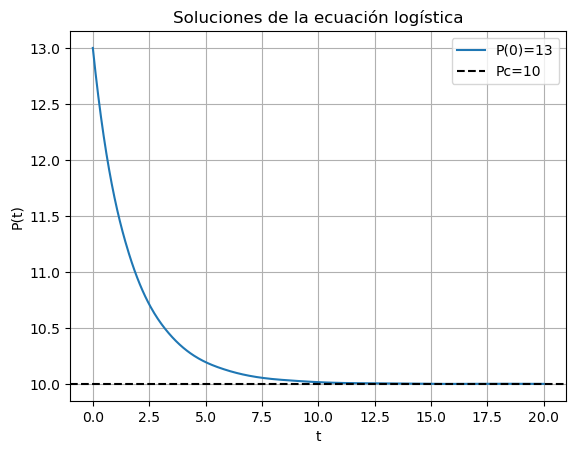

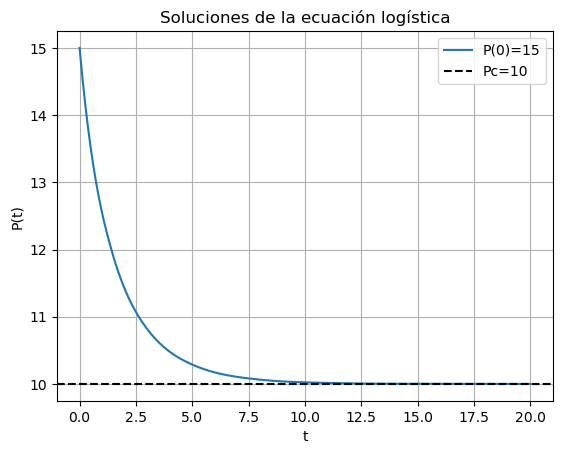

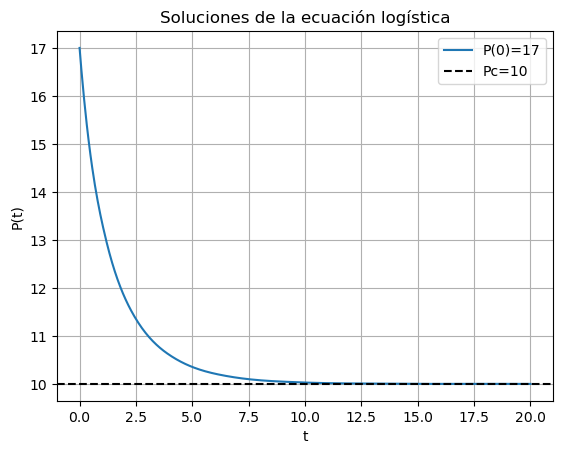

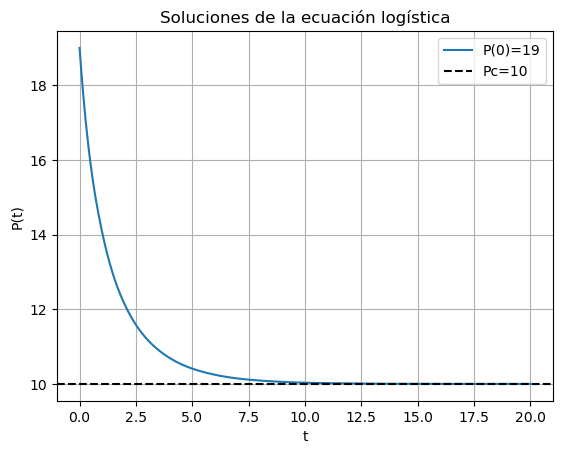

In [52]:

plt.figure(figsize=(10,6))

for P0 in range(1,20,2):
    sol = solve_ivp(
    poblacion,
    [0,20],
    [P0],
    t_eval=t_eval,
    args=(0.5,10))
    plt.plot(sol.t, sol.y[0], label=f"P(0)={P0}")
    plt.axhline(10, linestyle="--", color="black", label="Pc=10")
    plt.title("Soluciones de la ecuación logística")
    plt.xlabel("t")
    plt.ylabel("P(t)")
    plt.grid()
    plt.legend()
    plt.show()

4. Tome la solución con $P(0)=3$ del problema anterior. Encuentre la máxima diferencia dicha solución y la función
$$
P(t) = \frac{ 30e^{t/2} }{ 10+3(e^{t/2} -1)}
$$
Haga la gráfica de la diferencia en valor absoluto entre la función anterior y la solución numérica

In [73]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

Error máximo = 0.0047360702105727626


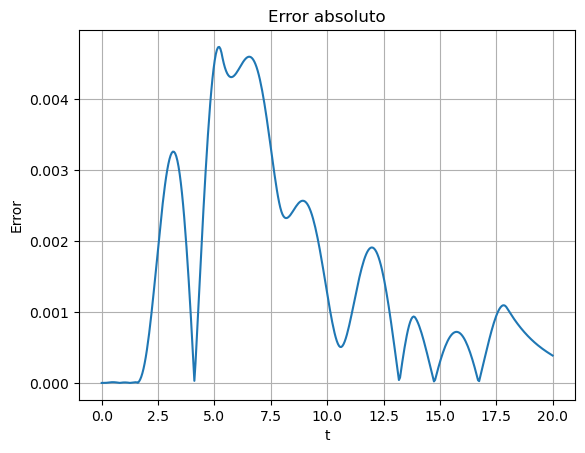

In [82]:
def poblacion(t, P, r, Pc):
    return [r * P[0] * (1 - P[0]/Pc)]

sol = solve_ivp(
    poblacion,
    [0,20],
    [3],
    t_eval=np.linspace(0,20,400),
    args=(0.5,10)
)

t = sol.t
P_num = sol.y[0]

P_exacta = (30*np.exp(t/2)) / (10 + 3*(np.exp(t/2) - 1))

diferencia = P_num - P_exacta

error = np.abs(diferencia)

print("Error máximo =", np.max(error))

plt.plot(t, np.abs(diferencia))
plt.title("Error absoluto")
plt.xlabel("t")
plt.ylabel("Error")
plt.grid()
plt.show()
